In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Literal, Annotated
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
import os
import requests
import polyline

load_dotenv()

ORS_API_KEY = os.getenv("OPENROUTESERVICE_KEY")
OCM_API_KEY = os.getenv("OPENCHARGEMAP_KEY")

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

C:\Users\rohan\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Types
class TripDetails(BaseModel):
    origin: str | None = Field(default=None, description="Source or origin of the trip")

    destination: str | None = Field(default=None, description="Destination of the trip")

    is_round_trip: bool | None = Field(
        default=None, description="Whether the trip is a round trip"
    )


class RouteDetails(BaseModel):
    distance: int | None = Field(default=None, description="Total distance between origin and destination")

    time: int | None = Field(default=None, description="Total time required to travel the given distance")

    route_geometry: int | None = Field(default=None, description="Encoded polyline string representing the spatial route geometry")


class LLMMessage(BaseModel):
    message: str


class RouteApproval(BaseModel):
    is_approved: bool = Field(
        description="True if the user accepts the route. False if they reject it or ask to change origin/destination/details."
    )


class VehicleState(BaseModel):
    battery_soc: int | None = Field(default=None, description="Battery in Percentage", le=100, ge=-1)
    range_left: int | None = Field(default=None, description="Estimated remaining range in kilometers")


In [3]:
# state
class TripState(TypedDict):
    trip: TripDetails
    route: RouteDetails
    messages: Annotated[list, add_messages]
    trip_details_retrieved: bool
    route_details_found: bool
    route_approved: bool
    charging_station: list
    vehicle_state: VehicleState

In [4]:
# llm
structured_llm_trip_details_extractor = llm.with_structured_output(TripDetails)
structured_llm_vehicle_state_extractor = llm.with_structured_output(VehicleState)
structured_llm_route_approval = llm.with_structured_output(RouteApproval)
structured_llm_message = llm.with_structured_output(LLMMessage)

In [5]:
# helper functions
def get_coordinates(place_name: str):
    
    url = "https://api.openrouteservice.org/geocode/search"

    headers = {"Authorization": ORS_API_KEY}

    params = {"text": place_name, "size": 1}

    response = requests.get(url, headers=headers, params=params, timeout=10)

    response.raise_for_status()

    data = response.json()

    if not data.get("features"):
        return None

    coordinates = data["features"][0]["geometry"]["coordinates"]

    return coordinates[0], coordinates[1]


def get_route(origin: str, destination: str):

    start = get_coordinates(origin)
    end = get_coordinates(destination)

    if start is None or end is None:
        return None

    url = "https://api.openrouteservice.org/v2/directions/driving-car"

    headers = {"Authorization": ORS_API_KEY, "Content-Type": "application/json"}

    body = {"coordinates": [start, end]}

    response = requests.post(url, headers=headers, json=body, timeout=20)

    response.raise_for_status()

    data = response.json()

    route = data["routes"][0]

    return {
        "distance_km": round(route["summary"]["distance"] / 1000, 2),
        "duration_minutes": round(route["summary"]["duration"] / 60, 1),
        "geometry": route["geometry"],
    }


def get_charging_stations_along_route(
    geometry: str, sample_interval: int = 30, search_radius_km: int = 5
):
    coordinates = polyline.decode(geometry)

    if not coordinates:
        return []

    sampled_coordinates = coordinates[::sample_interval]

    if coordinates[-1] not in sampled_coordinates:
        sampled_coordinates.append(coordinates[-1])

    stations = {}
    url = "https://api.openchargemap.io/v3/poi/"
    headers = {"X-API-Key": OCM_API_KEY, "User-Agent": "EV-Trip_Planner"}

    for lat, lon in sampled_coordinates:
        params = {
            "latitude": lat,
            "longitude": lon,
            "distance": search_radius_km,
            "distanceunit": "KM",
            "maxresults": 20,
            "compact": True,
        }

        response = requests.get(url, headers=headers, params=params, timeout=15)

        if response.status_code != 200:
            continue

        for station in response.json():
            station_id = station.get("ID")
            if not station_id:
                continue

            address = station.get("AddressInfo", {})

            stations[station_id] = {
                "id": station_id,
                "name": address.get("Title"),
                "latitude": address.get("Latitude"),
                "longitude": address.get("Longitude"),
                "town": address.get("Town"),
                "state": address.get("StateOrProvince"),
                "address": address.get("AddressLine1"),
            }

    return list(stations.values())

In [6]:
# nodes
def extract_trip_details(state: TripState):
    print("extract_trip_details")

    prompt = f"""
        Extract the trip details from the conversation.
        If the user's response is ambiguous or unclear, do not extract the information.
        Do not overwrite existing values with `None`. Preserve previously collected information unless the user explicitly changes it.

        Current Trip:
        {state["trip"]}

        Conversation:
        {state["messages"]}

    """
    trip_details = structured_llm_trip_details_extractor.invoke(prompt)

    return {"trip": trip_details}


def validate_trip_details(state: TripState):
    print("validate_trip_details")

    trip = state["trip"]

    trip_details_retrieved = all(
        [
            trip.origin is not None,
            trip.destination is not None,
            trip.is_round_trip is not None,
        ]
    )

    return {"trip_details_retrieved": trip_details_retrieved}


def gather_trip_details(state: TripState):
    print("gather_trip_details")

    prompt = f"""
        You are an intelligent EV trip-planning assistant.
        
        Required Fields:
        {state["trip"]}

        Conversation:
        {state["messages"]}

        
        Have a natural conversation with the user.

        If any required field is missing, ask the user, but only one question at a time.

        If the user has not decided where to go, help them decide.

        If the user's response is ambiguous or unclear, ask a follow-up question to clarify before proceeding. Do not make assumptions.

        If user has declined to proceed ahead with further processing after calculating route details. Ask whether wants to change destination.

        Do not mention internal fields or technical details.
        Do not answer anything unrelated to EV trip planning.

    """

    response = structured_llm_message.invoke(prompt)

    return {"messages": [AIMessage(content=response.message)]}


def find_route_details(state: TripState):
    print("find_route_details")

    trip = state["trip"]

    route = get_route(trip.origin, trip.destination)

    route_details = {
        "distance": route["distance_km"],
        "time": route["duration_minutes"],
        "route_geometry": route["geometry"],
    }

    return {"route": route_details, "route_details_found": True}


def ask_for_route_confirmation(state: TripState):
    print("ask_for_route_confirmation")

    prompt = f"""

    You are an intelligent EV trip-planning assistant.
    Present the TRIP AND calculated ROUTE details to the user and ask if they want to proceed ahead with further planning.
    Present distance in KM and Time in HOURS & MINUTES.

    Current Trip: {state['trip']}
    Route Details: {state['route']}

    """
    response = structured_llm_message.invoke(prompt)

    return {"messages": [AIMessage(content=response.message)]}


def route_confirmation_extraction(state: TripState):
    print("route_confirmation_extraction")

    prompt = f"""

    Determine if the user approved the route or wants to make changes.

    Proposed Route: {state['route']}
    Conversation: {state['messages']}

    """
    response = structured_llm_route_approval.invoke(prompt)

    return { "route_approved": response.is_approved } 

def gather_vehicle_state_information(state: TripState):
    print("gather_vehicle_state_information")

    prompt = f"""
        You are an ev-trip planning agent

        Your job is to ask user about the battery and range left in there electric vehicle.

    """
    response = structured_llm_message.invoke(prompt)

    return {"messages": [AIMessage(content=response.message)]}


def extract_vehicle_state_information(state: TripState):
    print("extract_vehicle_state_information")

    prompt = f"""

    Extract the battery and range information from given context.

    Conversation: {state['messages']}

    """
    response = structured_llm_vehicle_state_extractor.invoke(prompt)

    return { "vehicle_state": response } 


def is_trip_possible_with_current_vehicle_state(state: TripState):
    print("is_trip_possible_with_current_vehicle_state")

    current_vehicle_state = state['vehicle_state']
    route_details = state["route"]

    if route_details["distance"] > current_vehicle_state.range_left:
        return {"messages": [AIMessage(content="Your current range is insufficient for this distance. Searching for optimal charging stations along your path...")]}

    return {"messages": [AIMessage(content="You have enough range to reach your destination directly. No charging stops required!")]}  
 

def find_charging_stations(state: TripState):
    print("find_charging_stations")

    route = state["route"]

    geometry = route.get("route_geometry")

    stations = get_charging_stations_along_route(geometry)

    return {"charging_station": stations}

In [7]:
# routers
def router_after_start(state: TripState) -> Literal["extract_trip_details", "route_confirmation_extraction", "extract_vehicle_state_information"]:

    if state['route_approved']:
        return "extract_vehicle_state_information"

    
    if state['route_details_found']:
        return "route_confirmation_extraction"

    return "extract_trip_details"


def router_trip_details(state: TripState) -> Literal["gather_trip_details", "find_route_details"]:

    if state["trip_details_retrieved"]:
        return "find_route_details"

    return "gather_trip_details"


def router_route_details(state: TripState) -> Literal["ask_for_route_confirmation", "gather_trip_details"]:
    
    if state['route'] is not None:
        return "ask_for_route_confirmation"

    return "gather_trip_details"


def router_route_approval(state: TripState) -> Literal["gather_vehicle_state_information", "gather_trip_details"]:
    
    if state['route_approved']:
        return "gather_vehicle_state_information"
    
    return "gather_trip_details"


def route_vehicle_state(state: TripState) -> Literal["find_charging_stations", END]:

    current_vehicle_state = state['vehicle_state']
    route_details = state["route"]
    
    if route_details["distance"] > current_vehicle_state.range_left:
        return "find_charging_stations"
    
    return END

In [8]:
graph = StateGraph(TripState)

graph.add_node("extract_trip_details", extract_trip_details)
graph.add_node("validate_trip_details", validate_trip_details)
graph.add_node("gather_trip_details", gather_trip_details)
graph.add_node("find_route_details", find_route_details)
graph.add_node("ask_for_route_confirmation", ask_for_route_confirmation)
graph.add_node("route_confirmation_extraction", route_confirmation_extraction)
graph.add_node("gather_vehicle_state_information", gather_vehicle_state_information)
graph.add_node("extract_vehicle_state_information", extract_vehicle_state_information)
graph.add_node("is_trip_possible_with_current_vehicle_state", is_trip_possible_with_current_vehicle_state)
graph.add_node("find_charging_stations", find_charging_stations)


In [9]:
graph.add_conditional_edges(START, router_after_start)
graph.add_edge("extract_trip_details", "validate_trip_details")
graph.add_conditional_edges("validate_trip_details", router_trip_details)
graph.add_edge("gather_trip_details", END)             
graph.add_edge("find_route_details", "ask_for_route_confirmation")
graph.add_edge("ask_for_route_confirmation", END)

graph.add_conditional_edges("route_confirmation_extraction", router_route_approval)
graph.add_edge("gather_vehicle_state_information", END)
graph.add_edge("extract_vehicle_state_information", "is_trip_possible_with_current_vehicle_state")
graph.add_conditional_edges("is_trip_possible_with_current_vehicle_state", route_vehicle_state)
graph.add_edge("find_charging_stations", END)




In [10]:
app = graph.compile()


In [11]:
state = {"trip": TripDetails(), "messages": [], "trip_details_retrieved": False, "route_details_found": False, "route_approved": False}


# while True:
#     user_input = input("You: ")

#     if user_input.lower() in ["exit", "quit"]:
#         break

#     state["messages"].append(HumanMessage(content=user_input))

#     state = app.invoke(state)

#     ai_message = state["messages"][-1]

#     print(f"AI: {ai_message.content}\n")

#     stations = state.get("charging_station")
    
#     if stations:
#         print(f"{stations}")
#         break




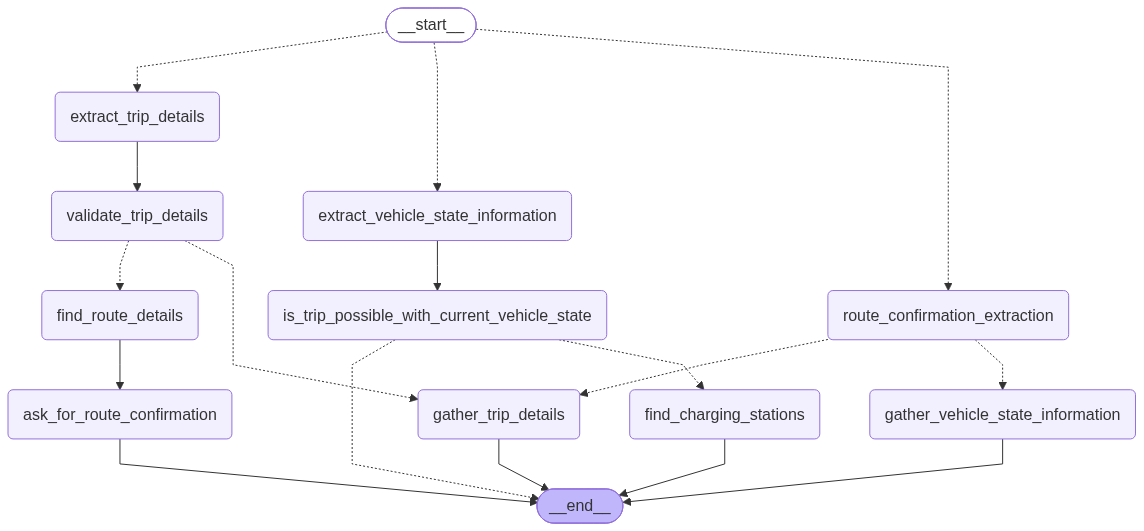

In [12]:
app